# Instructions

**Please follow these instructions carefully to ensure your submission is graded correctly:**

- Fill in **your answers** in any place that says "YOUR CODE HERE" or "YOUR ANSWER HERE" in the provided `.ipynb` files.

- Do not use print statements or the variable name `_` to display your answers; instead, make sure the last line of the cell contains the variable that holds your answer.

- Your answers to code-based questions must be **generated from code**. Hardcoded answers will result in a deduction of points.  

- Do not change the **autograding cells** labelled with `"AUTOGRADING CELL - DO NOT TOUCH!"`. Modifying or deleting them may lead to incorrect grading results.

- All plots must have appropriate **axis labels** including units where applicable. Failing to do so will result in a partial deduction of points.

- Always proide **units** for quantities where applicable. Failing to do so will result in a partial deduction of points.

- The **code quality** will not be graded. However, concise, well-structured code makes it easier to awared partial points in case of errors.

- The quality of **written answers** and **figures** will be considered during grading.

- Do not use additional packages that are not part of the course **environment**. This would lead to errors during autograding.

- Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).

- Submissions must be your own work, **plagiarism** from the web or peers will be checked for and sanctioned.

- Please upload only the provided `.ipynb` files, filled in with your answers.

- Please **do not** put the `.ipynb` files into archives (e.g., `.zip`, `.tar.gz`); also `.py` files will **not** be accepted. Please **do not change the file names** and do not upload additional files.

- Submission on ISIS *(for TU Berlin students)* requires **two-factor authentication**.

---

## Task 2: Danish Electricity Market Time Series (23 points)

Under the link below (`url`), you will find a CSV file with hourly time series on the electricity demand (in MW), the wind and solar generation (in MW), and the electricity prices (in €/MWh) for the market region DK1 (Western Denmark).

For the tasks listed below, all requested plots must be created with `matplotlib`. For all plots, choose suitable figure sizes, axis labels and line styles. Partial points will be deducted for incomplete or unclear plots.

In [3]:
url = "https://tubcloud.tu-berlin.de/s/qR5YN7XDfRSZNWQ/download/time-series.csv"

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**a)** Read the dataset into a `pandas.DataFrame` named `df`. The first column should parsed into the index as `pandas.DatetimeIndex`, the first row as column names. **(2 points)**

In [4]:
# YOUR CODE HERE
df = pd.read_csv(url, index_col=0, header=0)

In [5]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert "df" in globals()
assert isinstance(df, pd.DataFrame)

In [6]:
### AUTOGRADING CELL - DO NOT TOUCH!

**b)** What are the average values for each column in the dataset? Return the solution as a `pandas.Series`. **(2 points)**

In [9]:
# YOUR CODE HERE
df.mean(numeric_only=True)

DK_1_load_MW          2325.910652
DK_1_price_eur_MWh      38.499745
DK_1_solar_MW           71.650558
DK_1_wind_MW          1440.018841
dtype: float64

In [10]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.Series)

**c)** Normed by the maximum value of each column, which column has the lowest standard deviation? **(3 points)**

In [12]:
# YOUR CODE HERE
lowest_std = (df.std(numeric_only=True)/df.max(numeric_only=True)).idxmin()
lowest_std


'DK_1_load_MW'

In [13]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, str)

**d)** Find the timestamps where the electricity price is above 90 €/MWh. Return all hours where this is the case as a `pandas.DatetimeIndex`. **(3 points)**

In [17]:
# YOUR CODE HERE
pd.DatetimeIndex(df[df["DK_1_price_eur_MWh"] > 90].index)

DatetimeIndex(['2019-01-24 07:00:00', '2019-01-24 08:00:00',
               '2019-01-24 09:00:00', '2019-01-24 10:00:00',
               '2019-01-24 11:00:00', '2019-01-24 12:00:00',
               '2019-01-24 16:00:00', '2019-01-24 17:00:00',
               '2019-01-24 18:00:00', '2019-01-25 08:00:00',
               '2019-01-25 09:00:00'],
              dtype='datetime64[ns]', name='timestamp', freq=None)

In [18]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, pd.DatetimeIndex)

**e)** What percentage of hours does the sum of wind and solar generation exceed the electricity demand (in %)? **(3 points)**

In [60]:
# YOUR CODE HERE
sum(df["DK_1_solar_MW"] + df["DK_1_wind_MW"] > df["DK_1_load_MW"])/len(df) * 100

24.178082191780824

In [23]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

In [24]:
### AUTOGRADING CELL - DO NOT TOUCH!

**f)** What is the Pearson correlation coefficient between solar generation and electricity prices? Return the value as a `float`. **(2 point)**

In [25]:
# YOUR CODE HERE
df.corr(method="pearson")["DK_1_solar_MW"]["DK_1_price_eur_MWh"]

np.float64(-0.06337220930081838)

In [26]:
### AUTOGRADING CELL - DO NOT TOUCH!
assert isinstance(_, float)

**g)** Plot a scatter plot of wind generation against electricity prices. **(2 points)**

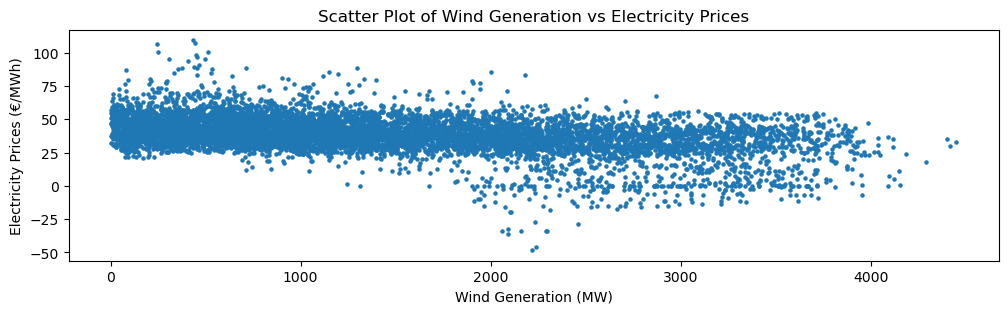

In [30]:
# YOUR CODE HERE
fig, ax = plt.subplots(figsize=(12, 3))
ax.scatter(df["DK_1_wind_MW"], df["DK_1_price_eur_MWh"], s=5)
ax.set_xlabel("Wind Generation (MW)")
ax.set_ylabel("Electricity Prices (€/MWh)")
ax.set_title("Scatter Plot of Wind Generation vs Electricity Prices")
plt.show()


**h)** Plot the hourly time series of wind generation, solar generation and electricity demand for the month of August. **(2 points)**

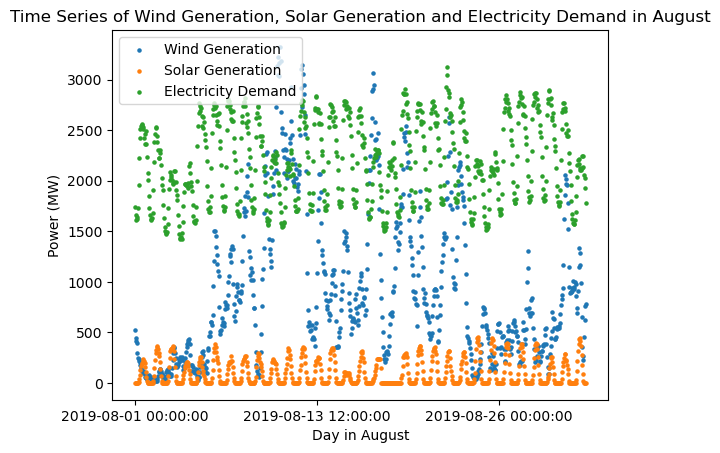

In [56]:
# YOUR CODE HERE
august_data = df[df.index.str.startswith("2019-08")]
fig, ax = plt.subplots()
ax.scatter(august_data.index, august_data["DK_1_wind_MW"], label="Wind Generation", s=5)
ax.scatter(august_data.index,august_data["DK_1_solar_MW"], label="Solar Generation", s=5)
ax.scatter(august_data.index, august_data["DK_1_load_MW"], label="Electricity Demand", s=5)
ax.set_xticks(august_data.index[::300])
ax.set_xlabel("Day in August")
ax.set_ylabel("Power (MW)")
ax.set_title("Time Series of Wind Generation, Solar Generation and Electricity Demand in August")
ax.legend()
plt.show()


**i)** Sort the price values in descending order and plot the price duration curve. The x-axis should be given as a percentage of the year. **(4 points)**

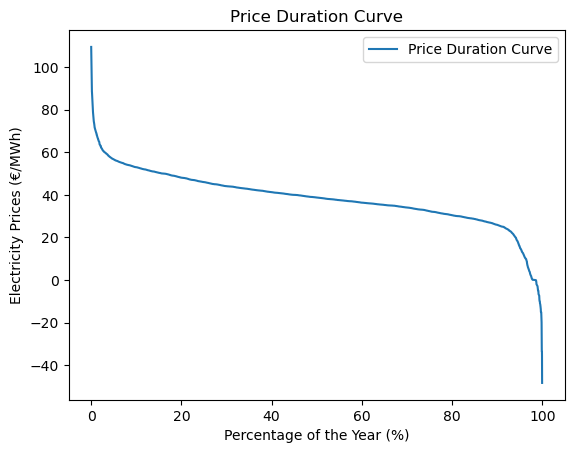

In [59]:
# YOUR CODE HERE
sorted_prices = df["DK_1_price_eur_MWh"].sort_values(ascending=False).reset_index(drop=True)
x_percentage = (sorted_prices.index / len(sorted_prices)) * 100
fig, ax = plt.subplots()
ax.plot(x_percentage, sorted_prices, label="Price Duration Curve")
ax.set_xlabel("Percentage of the Year (%)")
ax.set_ylabel("Electricity Prices (€/MWh)")
ax.set_title("Price Duration Curve")
ax.legend()
plt.show()
